<br>

## 1. Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score

<br>

## 2. Load Datasets & Set up

Load the ML-ready dataset and separate feature and target columns for modeling.

This dataset is already preprocessed, encoded, and scaled, making it suitable for direct use in machine learning models.

In [3]:
# Load datasets
df = pd.read_pickle('../Data/processed_data/ml_ready_data.pkl')
features_df = pd.read_pickle('../Data/processed_data/features_columns.pkl')
target_df = pd.read_pickle('../Data/processed_data/target_columns.pkl')

# Preview dataset
df.head()

,.NET,.NET Core,Angular,Angular.js,Ansible,Apache Spark,ASP.NET,ASP.NET Core,Assembly,Bash/Shell/PowerShell,...,front-end,full-stack,game or graphics,Marketing or sales professional,mobile,Product manager,QA or test,Scientist,Senior executive/VP,System administrator
0,1.724315,1.762893,-0.569413,-0.416451,-0.289751,-0.27559,2.257887,2.082232,-0.228229,-0.716789,...,0,1,0,0,0,0,0,0,0,0
1,-0.579940,-0.567249,-0.569413,-0.416451,-0.289751,-0.27559,-0.442892,-0.480254,-0.228229,-0.716789,...,0,1,0,0,1,0,0,0,0,0
2,-0.579940,-0.567249,-0.569413,-0.416451,-0.289751,-0.27559,-0.442892,-0.480254,-0.228229,-0.716789,...,1,0,0,0,1,0,0,0,0,0
3,-0.579940,-0.567249,-0.569413,-0.416451,3.451235,-0.27559,-0.442892,-0.480254,-0.228229,-0.716789,...,0,0,1,0,0,0,0,0,0,0
4,-0.579940,-0.567249,-0.569413,2.401240,-0.289751,-0.27559,-0.442892,-0.480254,-0.228229,-0.716789,...,0,1,0,0,0,0,0,0,0,0


In [4]:
# Extract column names
features_columns = features_df.columns
target_columns = target_df.columns

# Preview features and targets
df[features_columns].head()
df[target_columns].head()

,Academic researcher,back-end,Data or business analyst,Data scientist or machine learning specialist,Database administrator,Designer,desktop or enterprise applications,DevOps specialist,Educator,embedded applications or devices,...,front-end,full-stack,game or graphics,Marketing or sales professional,mobile,Product manager,QA or test,Scientist,Senior executive/VP,System administrator
0,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
2,0,0,0,0,0,1,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


<br>

## 3. Check Label Imbalace

We compute:
- Imbalance ratio
- Coefficient of variation (CV)

These metrics quantify the degree of imbalance in the label distribution.

Imbalace Ration =  70.72490706319702
Coefficient of Variation =  1.2590988499960978


Text(0.5, 1.0, 'Distribution of Label')

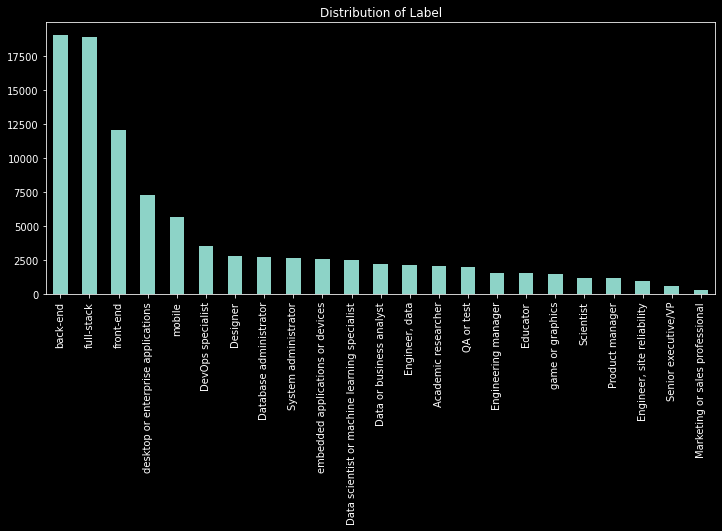

In [5]:
# Calculate label frequency
label_counts=df[target_columns].sum().sort_values(ascending=False)

# Imbalance Ratio: max frequency / min frequency
imbalance_ratio = label_counts.max() / label_counts.min()
print('Imbalace Ration = ',imbalance_ratio)

# Coefficient of Variation (CV): std / mean
cv = label_counts.std()/label_counts.mean()
print('Coefficient of Variation = ',cv)

# Plot label distribution
label_counts.plot(kind='bar',figsize=(12,5))
plt.title('Distribution of Label')

### Observations

- The label distribution is highly imbalanced.
- The imbalance ratio (~70.7) indicates a significant gap between the most frequent and least frequent job roles.
- The coefficient of variation (~1.26) confirms a high level of variability across label frequencies.

- A small number of roles dominate the dataset:
  - `Back-end`, `Full-stack` have the highest frequencies (above 17,500).

  - `Front-end`, `Desktop`, and `Mobile` roles are also common but significantly less dominant.

- Several roles such as `Marketing` and `Senior Executive/VP` have very low representation.

- Aside from these extremes, most roles fall within a moderate range (approximately 1,000–2,500), showing relative balance among mid-frequency classes.

<br>

### Impact on Modeling
- The dataset exhibits strong class imbalance, which can bias the model toward dominant roles.
- Accuracy is not an appropriate evaluation metric, as it would be misleading in this context.
- Evaluation should focus on:
  - **F1-score (micro)** for overall performance
  - **F1-score (macro)** to assess performance on rare roles

- Rare job roles require careful evaluation due to their low representation.

- This imbalance should be considered when selecting modeling strategies and during hyperparameter tuning.

<br>

## 4. Check Features Dependacy
Analyze dependencies and multicollinearity between feature variables (skills) using two complementary approaches:

1. Correlation coefficient heatmap
2. Variance Inflation Factor (VIF)

This step helps assess whether features are highly correlated, which may impact model selection and interpretation.

In [6]:
# 1. Correlation coefficient heatmap

# Compute correlation matrix for feature columns
corr_matrix = df[features_columns].corr()

# Visualize correlation matrix using a heatmap style
corr_matrix.style.background_gradient(cmap='coolwarm').set_precision(2)

C:\Users\Yousef Amer\AppData\Local\Temp\ipykernel_18156\3034959035.py:7: FutureWarning: this method is deprecated in favour of `Styler.format(precision=..)`
  corr_matrix.style.background_gradient(cmap='coolwarm').set_precision(2)


,.NET,.NET Core,Angular,Angular.js,Ansible,Apache Spark,ASP.NET,ASP.NET Core,Assembly,Bash/Shell/PowerShell,C,C#,C++,Cassandra,Chef,Cordova,Couchbase,Dart,Django,Drupal,DynamoDB,Elasticsearch,Express,Firebase,Flask,Flutter,Gatsby,Go,Hadoop,Haskell,HTML/CSS,IBM DB2,Java,JavaScript,jQuery,Julia,Keras,Kotlin,Laravel,MariaDB,Microsoft SQL Server,MongoDB,MySQL,Node.js,Objective-C,Oracle,Pandas,Perl,PHP,PostgreSQL,Puppet,Python,R,React Native,React.js,Redis,Ruby,Ruby on Rails,Rust,Scala,Spring,SQL,SQLite,Swift,Symfony,TensorFlow,Teraform,Torch/PyTorch,TypeScript,Unity 3D,Unreal Engine,VBA,Vue.js,Xamarin
.NET,1.00,0.72,0.10,0.09,-0.10,-0.09,0.68,0.59,0.02,-0.02,-0.01,0.71,0.05,-0.06,-0.02,-0.01,-0.02,-0.06,-0.11,-0.03,-0.06,-0.07,-0.11,-0.08,-0.12,-0.07,-0.08,-0.12,-0.06,-0.03,0.07,0.02,-0.12,0.03,0.12,-0.05,-0.08,-0.09,-0.08,-0.09,0.51,-0.06,-0.10,-0.02,-0.02,0.04,-0.12,-0.03,-0.08,-0.16,-0.03,-0.13,-0.04,-0.07,-0.07,-0.07,-0.09,-0.07,-0.07,-0.08,-0.13,0.16,0.02,-0.05,-0.07,-0.08,-0.07,-0.08,0.07,0.11,0.06,0.14,-0.03,0.31
.NET Core,0.72,1.00,0.14,0.06,-0.08,-0.08,0.57,0.79,-0.01,-0.00,-0.06,0.71,-0.01,-0.05,-0.02,-0.01,-0.01,-0.04,-0.12,-0.04,-0.03,-0.03,-0.09,-0.07,-0.10,-0.04,-0.06,-0.07,-0.06,-0.02,0.07,-0.00,-0.14,0.05,0.08,-0.05,-0.08,-0.07,-0.10,-0.09,0.51,-0.04,-0.14,0.01,-0.04,0.01,-0.12,-0.04,-0.12,-0.11,-0.02,-0.15,-0.06,-0.05,-0.03,-0.01,-0.08,-0.07,-0.03,-0.08,-0.12,0.14,0.00,-0.05,-0.07,-0.08,-0.03,-0.07,0.16,0.09,0.04,0.07,0.00,0.33
Angular,0.10,0.14,1.00,0.32,-0.03,-0.04,0.14,0.17,-0.05,-0.07,-0.07,0.10,-0.08,0.00,-0.01,0.14,0.02,0.02,-0.01,0.03,0.00,0.03,0.12,0.09,-0.04,0.06,0.01,-0.03,-0.01,-0.04,0.19,0.03,0.07,0.20,0.15,-0.05,-0.06,0.02,0.04,0.01,0.12,0.15,0.06,0.20,-0.04,0.11,-0.09,-0.04,0.03,-0.00,-0.01,-0.07,-0.05,0.07,0.11,0.01,-0.05,-0.02,-0.09,-0.02,0.15,0.07,-0.03,-0.03,0.02,-0.03,-0.04,-0.06,0.37,0.01,0.00,-0.01,0.10,0.07
Angular.js,0.09,0.06,0.32,1.00,-0.03,-0.03,0.13,0.08,-0.03,-0.06,-0.04,0.06,-0.03,0.00,-0.00,0.11,0.01,-0.01,0.02,0.04,0.00,0.00,0.07,0.04,-0.03,0.01,-0.00,-0.05,0.01,-0.04,0.15,0.02,0.05,0.18,0.22,-0.03,-0.05,-0.01,0.07,0.02,0.08,0.11,0.10,0.18,-0.01,0.10,-0.06,-0.01,0.09,-0.02,-0.01,-0.02,-0.02,0.09,0.15,-0.02,-0.01,0.03,-0.09,-0.02,0.06,0.08,0.00,-0.00,0.03,-0.02,-0.05,-0.04,0.12,0.03,0.01,0.00,0.10,0.05
Ansible,-0.10,-0.08,-0.03,-0.03,1.00,0.08,-0.08,-0.07,-0.00,0.16,0.00,-0.11,-0.03,0.09,0.19,-0.01,0.03,-0.03,0.06,-0.00,0.06,0.17,-0.02,-0.05,0.11,-0.03,-0.00,0.15,0.06,0.02,-0.05,0.02,0.03,-0.04,-0.04,-0.00,-0.00,0.01,-0.02,0.08,-0.06,0.02,-0.00,-0.02,-0.03,0.02,0.04,0.06,-0.02,0.13,0.17,0.09,-0.01,-0.04,-0.02,0.15,0.04,0.03,0.10,0.05,0.06,0.01,0.01,-0.04,0.03,0.01,0.26,0.01,-0.03,-0.04,-0.02,-0.03,-0.00,-0.05
Apache Spark,-0.09,-0.08,-0.04,-0.03,0.08,1.00,-0.07,-0.07,-0.02,0.05,-0.02,-0.10,-0.01,0.23,0.03,-0.03,0.04,-0.03,0.05,-0.02,0.09,0.16,-0.04,-0.04,0.12,-0.04,-0.03,0.06,0.44,0.04,-0.12,0.03,0.08,-0.10,-0.06,0.08,0.21,0.02,-0.04,-0.00,-0.02,0.03,0.00,-0.07,-0.03,0.05,0.26,-0.00,-0.07,0.09,0.03,0.12,0.14,-0.05,-0.05,0.07,-0.02,-0.02,0.01,0.32,0.09,0.06,-0.01,-0.04,-0.02,0.19,0.09,0.19,-0.08,-0.04,-0.03,-0.00,-0.06,-0.04
ASP.NET,0.68,0.57,0.14,0.13,-0.08,-0.07,1.00,0.67,-0.02,-0.04,-0.07,0.56,-0.04,-0.05,-0.02,0.01,-0.01,-0.04,-0.09,-0.01,-0.04,-0.04,-0.08,-0.04,-0.10,-0.04,-0.05,-0.10,-0.05,-0.05,0.14,0.02,-0.11,0.11,0.20,-0.04,-0.07,-0.08,-0.05,-0.08,0.50,-0.02,-0.06,0.02,-0.03,0.05,-0.11,-0.04,-0.05,-0.12,-0.02,-0.12,-0.04,-0.03,-0.01,-0.03,-0.07,-0.05,-0.09,-0.07,-0.10,0.19,0.00,-0.04,-0.05,-0.07,-0.06,-0.07,0.12,0.06,0.01,0.10,0.02,0.27
ASP.NET Core,0.59,0.79,0.17,0.08,-0.07,-0.07,0.67,1.00,-0.04,-0.02,-0.10,0.63,-0.07,-0.04,-0.01,-0.00,-0.01,-0.03,-0.10,-0.03,-0.02,-0.00,-0.06,-0.05,-0.10,-0.03,-0.04,-0.06,-0.06,-0.03,0.11,-0.00,-0.15,0.10,0.12,-0.04,-0.08,-0.08,-0.08,-0.08,0.52,-0.01,-0.12,0.02,-0.05,0.00,-0.11,-0.05,-0.10,-0.09,-0.02,-0.15,-0.06,-0.03,0.01,0.02,-0.08,-0.06,-0.05,-0.07,-0.11,0.16,-0.01,-0.05,-0.06,-0.08,-0.03,-0.07,0.19,0.05,0.01,0.06,0.03,0.30
Assembly,0.02

In [7]:
# 2. Variance Inflation Factor (VIF)

# Initialize dataframe to store VIF results
vif_data = pd.DataFrame()

# Store feature names
vif_data["feature"] = features_columns

# Compute VIF for each feature
vif_data["VIF"] = [
    variance_inflation_factor(df[features_columns].values, i)
    for i in range(len(df[features_columns].columns))
    ]

# Sort features by VIF in descending order
# Higher VIF → stronger multicollinearity
vif_data=vif_data.sort_values(by=["VIF"],ascending=False)

vif_data


,feature,VIF
1,.NET Core,3.975139
7,ASP.NET Core,3.525091
0,.NET,3.203647
11,C#,2.698898
6,ASP.NET,2.536045
...,...,...
15,Cordova,1.060628
19,Drupal,1.057918
47,Perl,1.053203
16,Couchbase,1.035560



### Observations

- Overall, feature correlations between skills are generally low, indicating that most technologies are relatively independent.
- A few moderate correlations exist between related technologies, such as:
  - "Hadoop" , 'Apache Spark'  (0.44)
  - "C" , "C++"  (0.49)
  - "Flutter" , "Dart"  (0.58)

- Higher correlations are observed within the .NET ecosystem:
  - ".NET" , ".NET Core" (0.72)
  - "ASP.NET Core" , ".NET Core" (0.79)
  - "C#" , (".NET" / ".NET Core") (~0.70+)
  - "ASP.NET" , (".NET Core" / "ASP.NET Core") (0.57–0.68)

- VIF results confirm the same pattern:
  - All features have relatively low multicollinearity (VIF < 5)
  - The highest VIF values are within the .NET-related features (≈ 2.5–4.0)

- Observed dependencies mainly reflect technological relationships between tools rather than redundancy.

<br>



### Impact on Modeling

- The assumption of feature independence is largely reasonable for most models, including Naive Bayes.
- Localized dependencies exist within technology families (especially the .NET ecosystem), which may:
  - Slightly violate independence assumptions in probabilistic models
  - Introduce redundancy in linear models

- Tree-based models are less affected by these dependencies, while linear models (e.g., Logistic Regression) may benefit from regularization.

<br>


### Plan

To address structured dependencies while preserving information:

1. Create a higher-level aggregated feature:
   - `.NET_ecosystem` → combining all .NET-related technologies

2. Evaluate multiple feature representations:
   - Original feature set
   - Reduced feature set (with `.NET_ecosystem`)
   - Combined feature set (both original + aggregated)

3. Apply regularization in linear models to reduce impact of correlated features.

4. Compare all feature strategies using cross-validation to determine the most effective representation for modeling performance.

In [8]:
# Create aggregated feature representing the .NET ecosystem

# Since features were previously standardized,
#  we use (> 0) to recover original binary meaning:
df['.NET_ecosystem'] = (
    (df['.NET'] > 0) |
    (df['.NET Core'] > 0) |
    (df['ASP.NET'] > 0) |
    (df['ASP.NET Core'] > 0)
).astype(int)


# Standardize the new feature to maintain consistency with other features
# This ensures all features are on the same scale for modeling
df['.NET_ecosystem'] = zscore(df['.NET_ecosystem'])

# Add the new feature to the list of feature columns
features_columns = features_columns.append(pd.Index(['.NET_ecosystem']))


# Preview updated feature set including the new column
df[features_columns]

,.NET,.NET Core,Angular,Angular.js,Ansible,Apache Spark,ASP.NET,ASP.NET Core,Assembly,Bash/Shell/PowerShell,...,TensorFlow,Teraform,Torch/PyTorch,TypeScript,Unity 3D,Unreal Engine,VBA,Vue.js,Xamarin,.NET_ecosystem
0,1.724315,1.762893,-0.569413,-0.416451,-0.289751,-0.275590,2.257887,2.082232,-0.228229,-0.716789,...,-0.491218,-0.301320,-0.277403,-0.775574,-0.362515,-0.239225,-0.230578,-0.570162,3.823568,1.480207
1,-0.579940,-0.567249,-0.569413,-0.416451,-0.289751,-0.275590,-0.442892,-0.480254,-0.228229,-0.716789,...,2.035757,-0.301320,-0.277403,-0.775574,2.758506,-0.239225,-0.230578,-0.570162,-0.261536,-0.675581
2,-0.579940,-0.567249,-0.569413,-0.416451,-0.289751,-0.275590,-0.442892,-0.480254,-0.228229,-0.716789,...,-0.491218,-0.301320,-0.277403,-0.775574,-0.362515,-0.239225,-0.230578,-0.570162,-0.261536,-0.675581
3,-0.579940,-0.567249,-0.569413,-0.416451,3.451235,-0.275590,-0.442892,-0.480254,-0.228229,-0.716789,...,-0.491218,-0.301320,-0.277403,-0.775574,2.758506,-0.239225,-0.230578,1.753887,-0.261536,-0.675581
4,-0.579940,-0.567249,-0.569413,2.401240,-0.289751,-0.275590,-0.442892,-0.480254,-0.228229,-0.716789,...,-0.491218,-0.301320,-0.277403,-0.775574,-0.362515,-0.239225,-0.230578,-0.570162,-0.261536,-0.675581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36998,-0.579940,-0.567249,-0.569413,-0.416451,-0.289751,3.628573,-0.442892,-0.480254,-0.228229,-0.716789,...,-0.491218,3.318729,-0.277403,-0.775574,-0.362515,-0.239225,-0.230578,-0.570162,-0.261536,-0.675581
36999,-0.579940,-0.567249,-0.569413,-0.416451,-0.289751,-0.275590,-0.442892,-0.480254,-0.228229,1.395110,...,-0.491218,-0.301320,-0.277403,-0.775574,2.758506,4.180166,-0.230578,-0.570162,-0.261536,-0.675581
37000,-0.579940,-0.567249,1.756194,2.401240,-0.289751,-0.275590,-0.442892,-0.480254,-0.228229,-0.716789,...,2.035757,-0.301320,3.604869,1.289368,-0.362515,-0.239225,-0.230578,1.753887,-0.261536,-0.675581
37001,1.724315,-0.567249,-0.569413,-0.416451,-0.289751,-0.275590,-0.442892,-0.480254,-0.228229,-0.716789,...,-0.491218,-0.301320,-0.277403,-0.775574,-0.362515,4.180166,-0.230578,-0.570162,-0.261536,1.480207


<br>

## 4. Feature Set Evaluation

### Objective

Evaluate multiple machine learning models across different feature sets to identify the most effective feature representation.

<br>


### Approach
- We evaluate each feature set using multiple models from different learning families:
  - Logistic Regression (linear model)
  - Linear SVM (margin-based model)
  - Random Forest (tree-based model)
  - Naive Bayes (probabilistic model)

  Using multiple models ensures that the selected feature set performs well       **independently of a specific algorithm**, making it more robust and generalizable.


- Models such as Decision Trees and KNN were excluded because:
    - Decision Trees tend to overfit on high-dimensional sparse data
    - KNN performs poorly in high-dimensional spaces (curse of dimensionality)


- We use **5-fold Cross-Validation** to ensure robust and stable performance estimates
- The evaluation metric is **F1-micro**, which:
  - Handles class imbalance effectively
  - Aggregates performance across all labels
  - Is well-suited for multi-label classification problems


In [9]:
# Extract input features (X) and target labels (y)
X = df[features_columns]
y = df[target_columns]

# Split dataset into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2
)

In [10]:
# Define Feature Set Variations
# We evaluate three different feature configurations
X_sets = {
    "original": X_train.drop(columns=['.NET_ecosystem']),
    "dotNET_only": X_train.drop(columns=['.NET', '.NET Core', 'ASP.NET', 'ASP.NET Core']),
    "combined": X_train
}



# Define Models
models = {
    'lr': OneVsRestClassifier(LogisticRegression(max_iter=1000)),
    'rf': RandomForestClassifier(),
    'svc': OneVsRestClassifier(LinearSVC()),
    'nb': OneVsRestClassifier(GaussianNB())
}

In [11]:
# Cross-Validation Evaluation Loop

results=[]

for X_name,X in X_sets.items():
    for model_name, model in models.items():
        scores = cross_val_score(model, X, y_train, cv=5, scoring='f1_micro')
        score=scores.mean()
        results.append({
            'model': model_name,
            'feature_set': X_name,
            'score': score
        })

results_df = pd.DataFrame(results)
results_df.sort_values(by="score", ascending=False)
results_df

c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
c:\Users\Yousef Amer\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\svm\_base.py:1225: ConvergenceWarning: Liblinear failed to converge, increase the

,model,feature_set,score
0,lr,original,0.507062
1,rf,original,0.489990
2,svc,original,0.492635
3,nb,original,0.389286
4,lr,dotNET_only,0.504955
5,rf,dotNET_only,0.488733
6,svc,dotNET_only,0.490487
7,nb,dotNET_only,0.387600
8,lr,combined,0.507285
9,rf,combined,0.490784


In [12]:
# Reshape results into a pivot table for easier comparison
results_pivot_df = results_df.pivot(index='model', columns='feature_set', values='score')
results_pivot_df

feature_set,combined,dotNET_only,original
model,,,
lr,0.507285,0.504955,0.507062
nb,0.388685,0.387600,0.389286
rf,0.490784,0.488733,0.489990
svc,0.493020,0.490487,0.492635


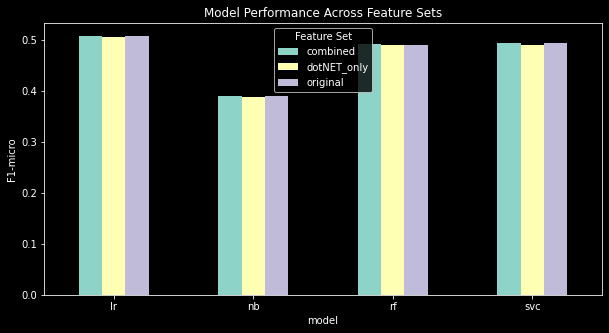

In [13]:
# Plot bar chart to visually compare model performance across feature sets
results_pivot_df.plot(kind='bar', figsize=(10,5))
plt.ylabel("F1-micro")
plt.title("Model Performance Across Feature Sets")
plt.xticks(rotation=0)
plt.legend(title="Feature Set")

### Observations

- Logistic Regression achieves the best performance across all feature sets, followed  by Linear SVM.
- Random Forest shows lower performance compared to linear models
- Naive Bayes performed significantly worse, likely due to its strong independence assumptions.

- The differences between feature sets are minimal:
  - The **combined** feature set performs slightly better overall.
  - The **original** feature set is very close in performance.
  - The **dotNET_only** feature set shows a small decrease in performance.

<br>

### Conclusion

- Feature engineering using `.NET_ecosystem` provides a **minor improvement**, but does not significantly change model performance.

- Linear models (Logistic Regression and Linear SVM) are more suitable for this dataset than tree-based or probabilistic models.

<br>

### Plan

- The **combined feature set** is selected for the next stage
- Focus on the following models:
  - Logistic Regression
  - Linear SVM
  - Random Forest (as a secondary comparison)
- Move to the next stage for model selection and tuning.

<br>

## 5. Saving Modeling datasets <br>

We save the processed datasets to be used in the modeling stage.
- Feature matrix (X)
- Target labels (y)

These files will be used directly in the modeling notebook.

In [15]:
# Save final feature matrix (X)
X = df[features_columns]
X.to_pickle('../Data/processed_data/X_features.pkl')


# Save target labels (y)
y = df[target_columns]
y.to_pickle('../Data/processed_data/y_target.pkl')